LIBRARIES

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)

DATA LOADING

In [2]:
streaming_df = pd.read_csv("../data/streaming_history.csv")

survey_df = pd.read_excel("../data/Spotify_data.xlsx")

tracks_df = pd.read_csv("../data/spotify_2015_2025_85k.csv")

# Dataset Shapes

Understanding:
- number of rows
- number of columns
- relative dataset sizes

In [3]:
print("Streaming Data Shape:", streaming_df.shape)

print("Survey Data Shape:", survey_df.shape)

print("Tracks Data Shape:", tracks_df.shape)

Streaming Data Shape: (57508, 14)
Survey Data Shape: (520, 20)
Tracks Data Shape: (85000, 19)


In [4]:
streaming_df.columns.tolist()


['ts',
 'platform',
 'ms_played',
 'conn_country',
 'track_name',
 'artist_name',
 'album_name',
 'track_uri',
 'reason_start',
 'reason_end',
 'shuffle',
 'skipped',
 'offline',
 'incognito_mode']

In [5]:
survey_df.columns.tolist()

['Age',
 'Gender',
 'spotify_usage_period',
 'spotify_listening_device',
 'spotify_subscription_plan',
 'premium_sub_willingness',
 'preffered_premium_plan',
 'preferred_listening_content',
 'fav_music_genre',
 'music_time_slot',
 'music_Influencial_mood',
 'music_lis_frequency',
 'music_expl_method',
 'music_recc_rating',
 'pod_lis_frequency',
 'fav_pod_genre',
 'preffered_pod_format',
 'pod_host_preference',
 'preffered_pod_duration',
 'pod_variety_satisfaction']

In [6]:
tracks_df.columns.tolist()


['track_id',
 'track_name',
 'artist_name',
 'album_name',
 'release_date',
 'genre',
 'duration_ms',
 'popularity',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'instrumentalness',
 'tempo',
 'stream_count',
 'country',
 'explicit',
 'label']

In [7]:
streaming_df.head()


,ts,platform,ms_played,conn_country,track_name,artist_name,album_name,track_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode
0,2020-06-21T13:35:24.000000,Windows 10 (10.0.19041; x64; AppX),205906,IN,Let Me Love You,DJ Snake,Encore,spotify:track:5Qjv35Ja2TDt9CXRRo51hh,playbtn,trackdone,False,False,False,False
1,2020-06-21T13:39:37.000000,Windows 10 (10.0.19041; x64; AppX),252534,IN,"Love Me Like You Do - From ""Fifty Shades Of Grey""",Ellie Goulding,Delirium,spotify:track:3zHq9ouUJQFQRf3cm1rRLu,trackdone,trackdone,True,False,False,False
2,2020-06-21T13:42:51.000000,Windows 10 (10.0.19041; x64; AppX),193266,IN,Mueve La Cintura,Pitbull,Libertad 548,spotify:track:6iLyEBNStoAemStXqGY7qP,trackdone,trackdone,True,False,False,False
3,2020-06-21T13:45:23.000000,Windows 10 (10.0.19041; x64; AppX),151133,IN,Lean On (with Emiway Bantai),Celina Sharma,Lean On (with Emiway Bantai),spotify:track:61eDLrQvquaTtZRnGFz9Kh,trackdone,endplay,True,False,False,False
4,2020-06-21T13:45:34.000000,Windows 10 (10.0.19041; x64; AppX),0,IN,Kabira,Pritam,Yeh Jawaani Hai Deewani,spotify:track:4bD9z9qa4qg9BhryvYWB7c,playbtn,endplay,True,False,False,False


In [8]:
survey_df.head()


,Age,Gender,spotify_usage_period,spotify_listening_device,spotify_subscription_plan,premium_sub_willingness,preffered_premium_plan,preferred_listening_content,fav_music_genre,music_time_slot,music_Influencial_mood,music_lis_frequency,music_expl_method,music_recc_rating,pod_lis_frequency,fav_pod_genre,preffered_pod_format,pod_host_preference,preffered_pod_duration,pod_variety_satisfaction
0,20-35,Female,More than 2 years,Smart speakers or voice assistants,Free (ad-supported),Yes,Family Plan-Rs 179/month,Podcast,Melody,Night,Sadness or melancholy,leisure time,Playlists,3,Daily,Comedy,Interview,Both,Both,Ok
1,12-20,Male,More than 2 years,Computer or laptop,Free (ad-supported),Yes,Individual Plan- Rs 119/ month,Podcast,Rap,Afternoon,Social gatherings or parties,Workout session,Playlists,2,Several times a week,Comedy,Interview,Both,NaN,Satisfied
2,35-60,Others,6 months to 1 year,Smart speakers or voice assistants,Free (ad-supported),Yes,Student Plan-Rs 59/month,Podcast,Pop,Night,Relaxation and stress relief,"Study Hours, While Traveling",Playlists,4,Once a week,Sports,Interview,NaN,Both,Satisfied
3,20-35,Female,1 year to 2 years,"Smartphone, Smart speakers or voice assistants",Free (ad-supported),No,NaN,Music,Melody,Night,"Relaxation and stress relief, Social gathering...","Office hours, Workout session, leisure time","recommendations, Playlists",4,Never,NaN,NaN,NaN,NaN,Ok
4,20-35,Female,1 year to 2 years,Smartphone,Free (ad-supported),No,NaN,Music,Melody,Night,Relaxation and stress relief,leisure time,"recommendations, Playlists",4,Rarely,Lifestyle and Health,Story telling,Well known individuals,Both,Ok


In [9]:
tracks_df.head()


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,4/1/2016,Pop,234194,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,4/15/2022,Metal,375706,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2/23/2016,Rock,289191,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,10/12/2015,Pop,209484,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,7/8/2022,Indie,127435,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent


# Dataset Information

This section helps identify:
- datatypes
- missing values
- categorical variables
- timestamps
- memory usage

In [17]:
streaming_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57508 entries, 0 to 57507
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ts              57508 non-null  object
 1   platform        57508 non-null  object
 2   ms_played       57508 non-null  int64 
 3   conn_country    57508 non-null  object
 4   track_name      57306 non-null  object
 5   artist_name     57306 non-null  object
 6   album_name      57306 non-null  object
 7   track_uri       57306 non-null  object
 8   reason_start    57508 non-null  object
 9   reason_end      57508 non-null  object
 10  shuffle         57508 non-null  bool  
 11  skipped         57508 non-null  bool  
 12  offline         57176 non-null  object
 13  incognito_mode  57508 non-null  bool  
dtypes: bool(3), int64(1), object(10)
memory usage: 5.0+ MB


In [11]:
survey_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Age                          520 non-null    object
 1   Gender                       520 non-null    object
 2   spotify_usage_period         520 non-null    object
 3   spotify_listening_device     520 non-null    object
 4   spotify_subscription_plan    520 non-null    object
 5   premium_sub_willingness      520 non-null    object
 6   preffered_premium_plan       312 non-null    object
 7   preferred_listening_content  520 non-null    object
 8   fav_music_genre              520 non-null    object
 9   music_time_slot              520 non-null    object
 10  music_Influencial_mood       520 non-null    object
 11  music_lis_frequency          520 non-null    object
 12  music_expl_method            520 non-null    object
 13  music_recc_rating            520 no

In [12]:
tracks_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          85000 non-null  object 
 1   track_name        84979 non-null  object 
 2   artist_name       85000 non-null  object 
 3   album_name        84954 non-null  object 
 4   release_date      85000 non-null  object 
 5   genre             85000 non-null  object 
 6   duration_ms       85000 non-null  int64  
 7   popularity        85000 non-null  int64  
 8   danceability      85000 non-null  float64
 9   energy            85000 non-null  float64
 10  key               85000 non-null  int64  
 11  loudness          85000 non-null  float64
 12  mode              85000 non-null  int64  
 13  instrumentalness  85000 non-null  float64
 14  tempo             85000 non-null  float64
 15  stream_count      85000 non-null  int64  
 16  country           85000 non-null  object

In [14]:
streaming_df.isnull().sum().sort_values(ascending=False)



offline           332
track_name        202
album_name        202
track_uri         202
artist_name       202
platform            0
ms_played           0
conn_country        0
ts                  0
reason_start        0
reason_end          0
shuffle             0
skipped             0
incognito_mode      0
dtype: int64

In [15]:
survey_df.isnull().sum().sort_values(ascending=False)

preffered_premium_plan         208
fav_pod_genre                  148
pod_host_preference            141
preffered_pod_format           140
preffered_pod_duration         129
spotify_usage_period             0
Gender                           0
Age                              0
spotify_listening_device         0
spotify_subscription_plan        0
premium_sub_willingness          0
preferred_listening_content      0
music_lis_frequency              0
music_Influencial_mood           0
music_time_slot                  0
fav_music_genre                  0
pod_lis_frequency                0
music_recc_rating                0
music_expl_method                0
pod_variety_satisfaction         0
dtype: int64

In [16]:
tracks_df.isnull().sum().sort_values(ascending=False)

album_name          46
track_name          21
track_id             0
artist_name          0
release_date         0
genre                0
duration_ms          0
popularity           0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
instrumentalness     0
tempo                0
stream_count         0
country              0
explicit             0
label                0
dtype: int64

DUPLICATED VALUES

In [18]:
print("Streaming Duplicates:", streaming_df.duplicated().sum())

print("Survey Duplicates:", survey_df.duplicated().sum())

print("Tracks Duplicates:", tracks_df.duplicated().sum())

Streaming Duplicates: 1416
Survey Duplicates: 1
Tracks Duplicates: 0


UNIQUE USER/TRACKS


In [19]:
streaming_df['track_name'].nunique()

7519

In [20]:
streaming_df['artist_name'].nunique()

2574

In [21]:
streaming_df['platform'].value_counts()

platform
android                                               22825
Android OS 7.0 API 24 (Xiaomi, Redmi Note 4)          13103
osx                                                    9657
Windows 10 (10.0.19042; x64; AppX)                     2338
Android-tablet OS 11 API 30 (SAMSUNG, SM-T870)         1466
                                                      ...  
web_player osx 10.15;firefox 101.0;desktop                9
OS X 12.5.0 [arm 2]                                       8
web_player windows 10;chrome 100.0.4896.75;desktop        8
web_player osx 10.15;firefox 98.0;desktop                 7
web_player osx 10.15;firefox 100.0;desktop                5
Name: count, Length: 46, dtype: int64

DATA CLEANING ( STREAMING DATA )

In [22]:
streaming_df.drop_duplicates(inplace=True)

In [23]:
streaming_df['ts'] = pd.to_datetime(streaming_df['ts'])

In [24]:
streaming_df.columns = streaming_df.columns.str.lower().str.strip()

In [25]:
streaming_df.isnull().sum()

ts                  0
platform            0
ms_played           0
conn_country        0
track_name        191
artist_name       191
album_name        191
track_uri         191
reason_start        0
reason_end          0
shuffle             0
skipped             0
offline           302
incognito_mode      0
dtype: int64

In [47]:
streaming_df = streaming_df.dropna(
    subset=[
        'track_name',
        'artist_name',
        'album_name',
        'track_uri',
        'offline'
    ]
)

In [48]:
streaming_df.isnull().sum()

ts                0
platform          0
ms_played         0
conn_country      0
track_name        0
artist_name       0
album_name        0
track_uri         0
reason_start      0
reason_end        0
shuffle           0
skipped           0
offline           0
incognito_mode    0
minutes_played    0
date              0
hour              0
day_name          0
month             0
week              0
is_weekend        0
skip_flag         0
night_listener    0
long_play         0
dtype: int64

In [28]:
streaming_df['minutes_played'] = streaming_df['ms_played'] / 60000

In [29]:
streaming_df = streaming_df[streaming_df['ms_played'] > 0]

CLEANING DATA ( SURVEY DATA )


In [30]:
survey_df.columns = survey_df.columns.str.lower().str.strip()


In [31]:
survey_df.drop_duplicates(inplace=True)

CLEAN TRACK METADATA

In [32]:
tracks_df.columns = tracks_df.columns.str.lower().str.strip()

In [33]:
tracks_df.drop_duplicates(inplace=True)


TIME FEATURE

In [34]:
streaming_df['date'] = streaming_df['ts'].dt.date

streaming_df['hour'] = streaming_df['ts'].dt.hour

streaming_df['day_name'] = streaming_df['ts'].dt.day_name()

streaming_df['month'] = streaming_df['ts'].dt.month

streaming_df['week'] = streaming_df['ts'].dt.isocalendar().week

streaming_df['is_weekend'] = streaming_df['day_name'].isin(['Saturday', 'Sunday'])

SKIP FEATURES

In [35]:
streaming_df['skip_flag'] = np.where(
    streaming_df['ms_played'] < 30000,
    1,
    0
)

NIGHT LISTENERS

In [36]:
streaming_df['night_listener'] = np.where(
    streaming_df['hour'].between(0, 5),
    1,
    0
)

LONG LISTENING

In [37]:
streaming_df['long_play'] = np.where(
    streaming_df['minutes_played'] > 10,
    1,
    0
)

LISTENING HOURS BY DAY

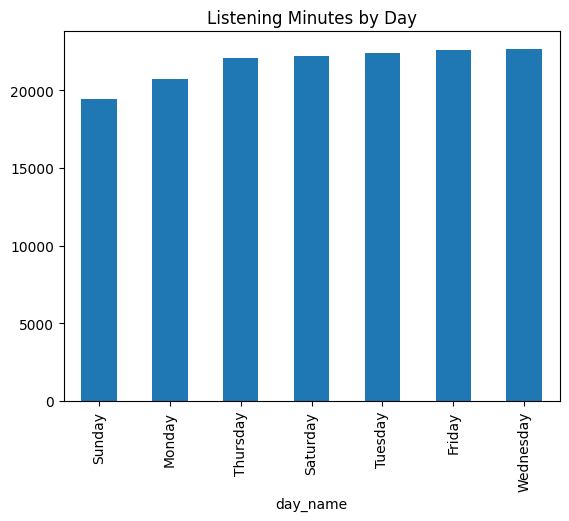

In [42]:
streaming_df.groupby('day_name')['minutes_played'].sum().sort_values().plot(kind='bar')

plt.title("Listening Minutes by Day")

plt.show()

HOURLY LISTENING BEHAVIOUE

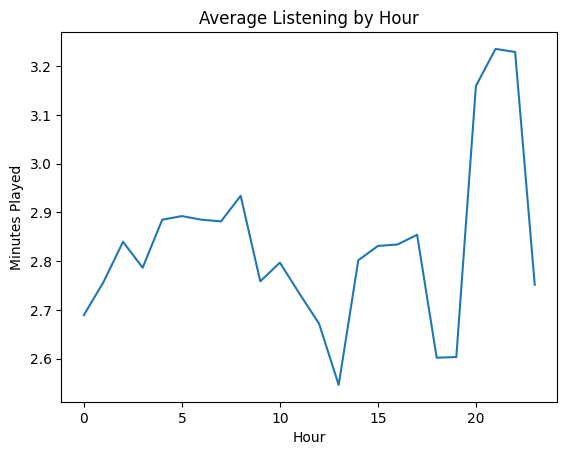

In [43]:
streaming_df.groupby('hour')['minutes_played'].mean().plot()

plt.title("Average Listening by Hour")

plt.xlabel("Hour")

plt.ylabel("Minutes Played")

plt.show()

CLEAN DATA TRANSFER


In [49]:
streaming_df.to_csv(
    "../cleaned_data/streaming_cleaned.csv",
    index=False
)

survey_df.to_csv(
    "../cleaned_data/survey_cleaned.csv",
    index=False
)

tracks_df.to_csv(
    "../cleaned_data/tracks_cleaned.csv",
    index=False
)